In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Path to the Series Matrix file
file_path = '/kaggle/input/fshd-dataset/Dataset2_GSE36398_series_matrix (1).txt'  # Replace with the actual file path

# Initialize an empty list to store the lines after the matrix table begins
matrix_data = []

# Open the Series Matrix file
with open(file_path, 'rt') as file:
    is_matrix = False
    for line in file:
        # Look for the line that indicates the start of the matrix
        if line.startswith("!series_matrix_table_begin"):
            is_matrix = True
            continue  # Skip this line, the matrix starts after it
        elif line.startswith("!series_matrix_table_end"):
            break  # Stop when we reach the end of the matrix

        # If we are in the matrix part, collect the lines
        if is_matrix:
            matrix_data.append(line.strip())



In [2]:
headers = matrix_data[0].split('\t')

# The rest of the lines contain the data for each gene/probe
data = [line.split('\t') for line in matrix_data[1:]]

# Create the DataFrame
df = pd.DataFrame(data, columns=headers)

In [3]:
df.head()

,"""ID_REF""","""GSM892341""","""GSM892342""","""GSM892343""","""GSM892344""","""GSM892345""","""GSM892346""","""GSM892347""","""GSM892348""","""GSM892349""",...,"""GSM892381""","""GSM892382""","""GSM892383""","""GSM892384""","""GSM892385""","""GSM892386""","""GSM892387""","""GSM892388""","""GSM892389""","""GSM892390"""
0,7892501,2.69436,4.14421,3.71685,4.91865,4.36051,6.15274,4.87124,2.6812,2.37867,...,2.58022,2.34025,2.6575,2.32534,2.52095,2.52999,3.08851,2.95307,2.19638,2.92756
1,7892502,5.36362,4.82062,5.14681,4.96349,5.22542,5.08787,5.05183,4.9384,5.14289,...,4.77709,5.32276,5.22259,4.71483,4.47399,5.35785,4.44756,4.83425,4.86621,4.29354
2,7892503,3.29625,4.139,3.4495,4.45905,3.36257,3.93171,4.50758,4.3835,3.29511,...,3.70415,3.15909,3.59883,3.23366,3.66587,3.46491,2.6699,3.34483,3.29887,3.19826
3,7892504,9.32365,9.42975,9.2081,9.06239,9.25775,9.4629,9.71636,9.70411,9.59551,...,8.64995,9.05828,9.13113,8.85675,8.93359,8.8838,9.30212,9.28771,8.75881,8.86856
4,7892505,3.25822,3.99531,2.93149,3.77013,3.72848,4.47241,3.13487,3.40859,3.3599,...,3.27102,3.61036,3.01398,2.99226,3.50909,3.19207,3.21607,3.31852,3.61308,3.42225


In [4]:
df.columns = df.columns.str.replace('"', '')

In [5]:
df.shape

(33297, 51)

In [6]:
# Transpose the dataframe
df = df.T

# Set the first row as the header
df.columns = df.iloc[0]

# Create a new column 'sample_id' with the previous column headers
df['sample_id'] = df.index

# Drop the first row since it's now used as headers
df = df.drop(index=df.index[0])

# Reset index if necessary
df.reset_index(drop=True, inplace=True)
df.columns.name = None

df.head()

,7892501,7892502,7892503,7892504,7892505,7892506,7892507,7892508,7892509,7892510,...,8180410,8180411,8180412,8180413,8180414,8180415,8180416,8180417,8180418,sample_id
0,2.69436,5.36362,3.29625,9.32365,3.25822,3.85351,5.08983,4.32527,11.503,2.68308,...,10.12021,7.57741,7.62879,7.46366,6.58976,6.66664,6.04219,8.73181,7.35747,GSM892341
1,4.14421,4.82062,4.139,9.42975,3.99531,4.21746,5.75516,4.7584,11.19746,4.16306,...,10.19191,7.69751,7.45021,7.26517,6.17724,6.44513,6.29065,8.55077,7.53255,GSM892342
2,3.71685,5.14681,3.4495,9.2081,2.93149,4.22158,4.62311,4.91811,11.74478,3.42031,...,10.25091,7.40726,7.80967,7.59174,6.22361,6.8076,5.7994,8.7478,8.11136,GSM892343
3,4.91865,4.96349,4.45905,9.06239,3.77013,3.69635,5.32378,5.26901,11.50871,3.71582,...,10.3916,7.54428,7.49888,7.29813,6.37809,6.46073,6.12713,8.58399,6.58152,GSM892344
4,4.36051,5.22542,3.36257,9.25775,3.72848,3.53138,4.70359,5.28222,11.43595,4.81427,...,10.23121,7.62352,7.37203,7.1681,6.42264,6.86699,5.78777,8.88992,7.35455,GSM892345


In [7]:
data = {
    'sample_id': ['GSM892341', 'GSM892342', 'GSM892343', 'GSM892344', 'GSM892345', 
               'GSM892346', 'GSM892347', 'GSM892348', 'GSM892349', 'GSM892350',
               'GSM892351', 'GSM892352', 'GSM892353', 'GSM892354', 'GSM892355', 
               'GSM892356', 'GSM892357', 'GSM892358', 'GSM892359', 'GSM892360',
               'GSM892361', 'GSM892362', 'GSM892363', 'GSM892364', 'GSM892365',
               'GSM892366', 'GSM892367', 'GSM892368', 'GSM892369', 'GSM892370',
               'GSM892371', 'GSM892372', 'GSM892373', 'GSM892374', 'GSM892375',
               'GSM892376', 'GSM892377', 'GSM892378', 'GSM892379', 'GSM892380',
               'GSM892381', 'GSM892382', 'GSM892383', 'GSM892384', 'GSM892385',
               'GSM892386', 'GSM892387', 'GSM892388', 'GSM892389', 'GSM892390'],
    
    'Disease': ['FSHD', 'FSHD', 'Normal', 'Normal', 'FSHD', 
                'FSHD', 'Normal', 'Normal', 'FSHD', 'FSHD',
                'Normal', 'Normal', 'FSHD', 'FSHD', 'FSHD', 
                'FSHD', 'Normal', 'Normal', 'Normal', 'Normal',
                'FSHD', 'FSHD', 'Normal', 'Normal', 'FSHD', 
                'FSHD', 'Normal', 'Normal', 'FSHD', 'FSHD',
                'Normal', 'Normal', 'FSHD', 'FSHD', 'Normal', 
                'Normal', 'FSHD', 'FSHD', 'Normal', 'Normal',
                'FSHD', 'FSHD', 'FSHD', 'FSHD', 'Normal', 
                'Normal', 'FSHD', 'FSHD', 'Normal', 'Normal']
}

data_df = pd.DataFrame(data)

In [8]:
data_df

,sample_id,Disease
0,GSM892341,FSHD
1,GSM892342,FSHD
2,GSM892343,Normal
3,GSM892344,Normal
4,GSM892345,FSHD
5,GSM892346,FSHD
6,GSM892347,Normal
7,GSM892348,Normal
8,GSM892349,FSHD
9,GSM892350,FSHD


In [9]:
# Merging the dataframes on the 'ID_REF' column
df = pd.merge(df, data_df, on='sample_id', how='inner')

In [10]:
df[['sample_id', 'Disease']]

,sample_id,Disease
0,GSM892341,FSHD
1,GSM892342,FSHD
2,GSM892343,Normal
3,GSM892344,Normal
4,GSM892345,FSHD
5,GSM892346,FSHD
6,GSM892347,Normal
7,GSM892348,Normal
8,GSM892349,FSHD
9,GSM892350,FSHD


## Data Preprocessing

In [11]:
from sklearn.preprocessing import LabelEncoder

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Assuming 'target_column' is the binary target column in your dataframe
df['disease'] = label_encoder.fit_transform(df['Disease'])

In [12]:
X = df.drop(['Disease', 'sample_id'], axis = 1)
y = df[['disease']]

In [13]:
X.head()

,7892501,7892502,7892503,7892504,7892505,7892506,7892507,7892508,7892509,7892510,...,8180410,8180411,8180412,8180413,8180414,8180415,8180416,8180417,8180418,disease
0,2.69436,5.36362,3.29625,9.32365,3.25822,3.85351,5.08983,4.32527,11.503,2.68308,...,10.12021,7.57741,7.62879,7.46366,6.58976,6.66664,6.04219,8.73181,7.35747,0
1,4.14421,4.82062,4.139,9.42975,3.99531,4.21746,5.75516,4.7584,11.19746,4.16306,...,10.19191,7.69751,7.45021,7.26517,6.17724,6.44513,6.29065,8.55077,7.53255,0
2,3.71685,5.14681,3.4495,9.2081,2.93149,4.22158,4.62311,4.91811,11.74478,3.42031,...,10.25091,7.40726,7.80967,7.59174,6.22361,6.8076,5.7994,8.7478,8.11136,1
3,4.91865,4.96349,4.45905,9.06239,3.77013,3.69635,5.32378,5.26901,11.50871,3.71582,...,10.3916,7.54428,7.49888,7.29813,6.37809,6.46073,6.12713,8.58399,6.58152,1
4,4.36051,5.22542,3.36257,9.25775,3.72848,3.53138,4.70359,5.28222,11.43595,4.81427,...,10.23121,7.62352,7.37203,7.1681,6.42264,6.86699,5.78777,8.88992,7.35455,0


In [14]:
y.head()

,disease
0,0
1,0
2,1
3,1
4,0


## Dimensionality Reduction

In [15]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=50)
# x_reduced = pca.fit_transform(X)




## Train Test Split

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

In [17]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(40, 33298)
(40, 1)
(10, 33298)
(10, 1)


## Data Normalization

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

# List of classifiers
classifiers = {
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'k-NN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(),
    'Gradient Boosting': GradientBoostingClassifier()
}


Classifier: Random Forest


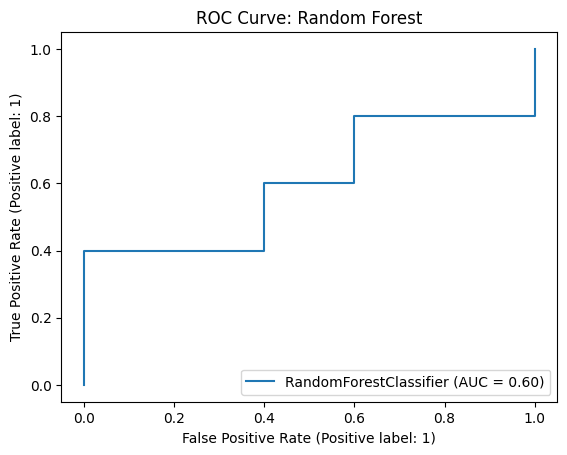

Accuracy: 0.6000
F1 Score: 0.6000
Recall: 0.6000
Confusion Matrix:
[[3 2]
 [2 3]]
ROC AUC Score: 0.6000

Classifier: SVM


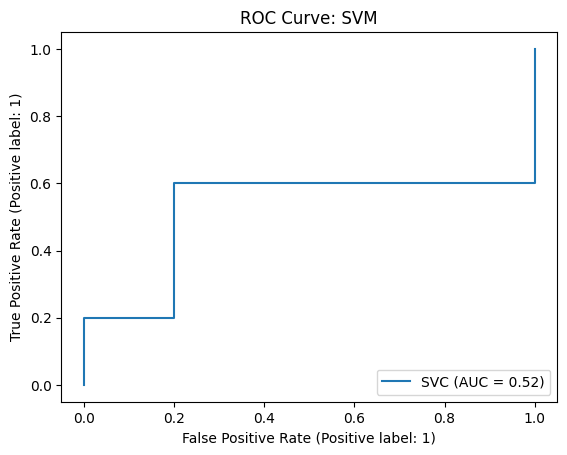

Accuracy: 0.3000
F1 Score: 0.2929
Recall: 0.3000
Confusion Matrix:
[[1 4]
 [3 2]]
ROC AUC Score: 0.5200

Classifier: k-NN


OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

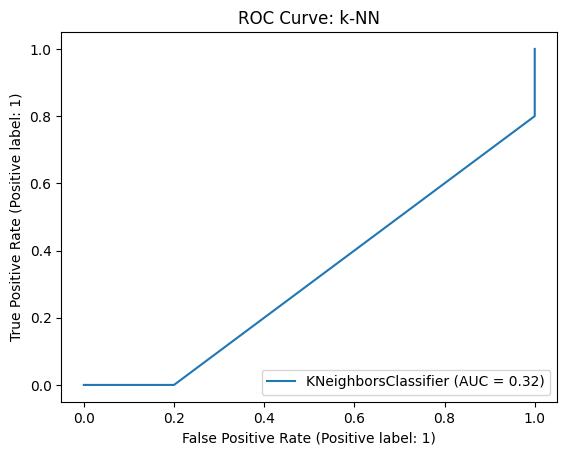

Accuracy: 0.4000
F1 Score: 0.3750
Recall: 0.4000
Confusion Matrix:
[[1 4]
 [2 3]]
ROC AUC Score: 0.3200

Classifier: Naive Bayes


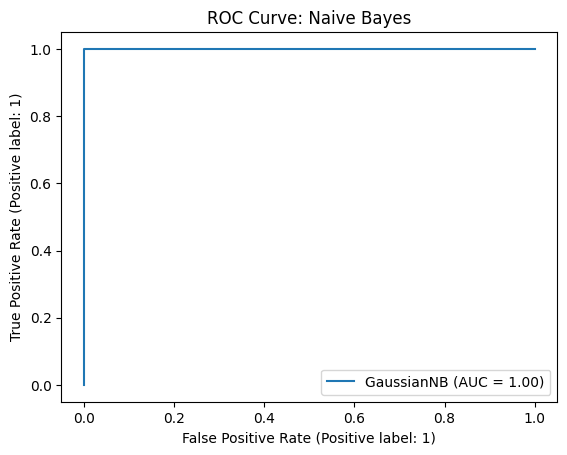

Accuracy: 1.0000
F1 Score: 1.0000
Recall: 1.0000
Confusion Matrix:
[[5 0]
 [0 5]]
ROC AUC Score: 1.0000

Classifier: Logistic Regression


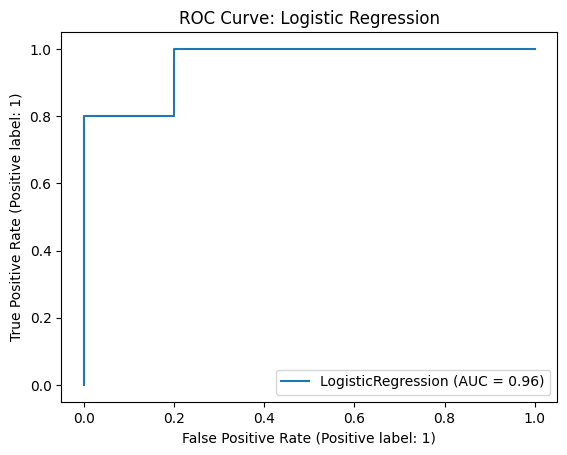

Accuracy: 0.8000
F1 Score: 0.7917
Recall: 0.8000
Confusion Matrix:
[[3 2]
 [0 5]]
ROC AUC Score: 0.9600

Classifier: Gradient Boosting


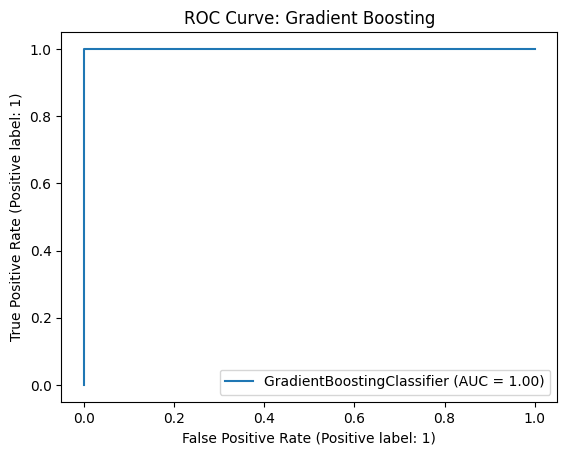

Accuracy: 1.0000
F1 Score: 1.0000
Recall: 1.0000
Confusion Matrix:
[[5 0]
 [0 5]]
ROC AUC Score: 1.0000


In [20]:
# Loop through classifiers
for name, clf in classifiers.items():
    print(f"\nClassifier: {name}")
    
    # Train the classifier
    clf.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
    
    # Accuracy, F1, Recall
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # ROC AUC score
    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        RocCurveDisplay.from_estimator(clf, X_test_scaled, y_test)
        plt.title(f"ROC Curve: {name}")
        plt.show()
    else:
        roc_auc = None
    
    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    if roc_auc is not None:
        print(f"ROC AUC Score: {roc_auc:.4f}")

## Data Augmentation

In [21]:
import pywt

def wt_decompose(X, wavelet='db1', level=1):
    coeffs = [pywt.wavedec(x, wavelet, level=level) for x in X]
    # Stack coefficients into arrays per subband
    # Here level=1: coeffs[i] = [cA, cD]
    cA = np.stack([c[0] for c in coeffs])
    cD = np.stack([c[1] for c in coeffs])
    return cA, cD

def wt_reconstruct(cA, cD, wavelet='db1'):
    X_rec = [pywt.waverec([cA[i], cD[i]], wavelet) for i in range(len(cA))]
    return np.stack(X_rec)

cA, cD = wt_decompose(X_train_scaled, level=1)


In [22]:
import numpy as np
import pywt
import tensorflow as tf
from tensorflow.keras import layers, Model

# 2) Build simple GAN on cA subband (same for cD or jointly)
dim = cA.shape[1]
# Generator
z_dim = 10
z = layers.Input(shape=(z_dim,))
g = layers.Dense(128, activation='relu')(z)
g = layers.Dense(dim, activation='linear')(g)
generator = Model(z, g)

# Discriminator
x = layers.Input(shape=(dim,))
d = layers.Dense(128, activation='relu')(x)
d = layers.Dense(1, activation='sigmoid')(d)
discriminator = Model(x, d)
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# GAN
discriminator.trainable = False
gan_input = layers.Input(shape=(z_dim,))
gan_output = discriminator(generator(gan_input))
gan = Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

2025-06-08 05:00:59.689014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749358859.949337      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749358860.034350      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-08 05:01:14.171891: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [23]:
# 3) Train GAN
batch_size = 8
epochs = 50
for epoch in range(epochs):
    # train discriminator
    idx = np.random.randint(0, cA.shape[0], batch_size)
    real = cA[idx]
    noise = np.random.normal(0, 1, (batch_size, z_dim))
    fake = generator.predict(noise)
    d_loss_real = discriminator.train_on_batch(real, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake, np.zeros((batch_size,1)))
    # train generator
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

In [24]:
# 4) Generate synthetic wavelet coeffs + reconstruct
n_synth = 50
noise = np.random.normal(0,1,(n_synth, z_dim))
cA_synth = generator.predict(noise)
# for detail band, you can either reuse real random cD samples or train separate GAN
cD_synth = cD[np.random.choice(len(cD), n_synth)]
X_synth = wt_reconstruct(cA_synth, cD_synth)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [25]:
X_synth

array([[-1.05747946,  1.00249909, -0.20675355, ...,  0.13784258,
        -0.04749007, -0.19296204],
       [ 0.53057153, -0.56830666, -0.71230801, ..., -1.4571763 ,
         1.02312338, -1.2613843 ],
       [-0.2834261 ,  0.23162762,  0.30225032, ..., -0.84868279,
         1.00209496, -1.12833166],
       ...,
       [-0.17256864,  0.25633127,  1.01468548, ..., -0.76442363,
         1.06013343, -1.45001483],
       [-1.17671856,  1.13485247,  1.1960436 , ..., -0.14954924,
        -1.10197478,  0.94510276],
       [ 0.19876146, -0.21492251,  0.59575574, ..., -0.0678137 ,
        -0.06542336, -0.14445686]])

In [26]:
n_synth = 50
noise = np.random.normal(0,1,(n_synth, z_dim))
cA_synth = generator.predict(noise)

# instead of “cD_synth = cD[np.random.choice(...)]” do this:
cD_indices = np.random.choice(len(cD), size=n_synth, replace=True)
cD_synth    = cD[cD_indices]

# now reconstruct
X_synth = wt_reconstruct(cA_synth, cD_synth)

# 4) pull synthetic labels from y_train using those same indices
y_synth = y_train.values[cD_indices]   # if y_train is a pandas Series
# or if y_train is numpy: y_synth = y_train[cD_indices]

y_real = y_train.values.ravel()
y_synth = y_synth.ravel()

# 5) combine with real data
X_aug = np.vstack([X_train_scaled, X_synth])
y_aug = np.hstack([y_real,           y_synth])

print("Augmented shape:", X_aug.shape, y_aug.shape)
print("Class counts:", np.bincount(y_aug))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Augmented shape: (90, 33298) (90,)
Class counts: [45 45]


In [27]:
print(X_synth.shape)
print(X_train_scaled.shape)

(50, 33298)
(40, 33298)


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

# List of classifiers
classifiers = {
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'k-NN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(),
    'Gradient Boosting': GradientBoostingClassifier()
}


Classifier: Random Forest


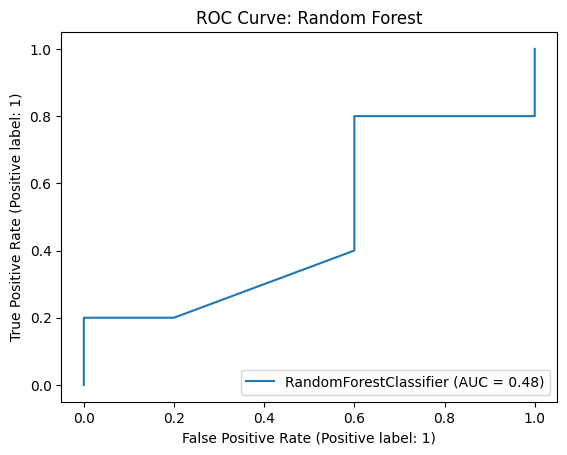

Accuracy: 0.4000
F1 Score: 0.2857
Recall: 0.4000
Confusion Matrix:
[[0 5]
 [1 4]]
ROC AUC Score: 0.4800

Classifier: SVM


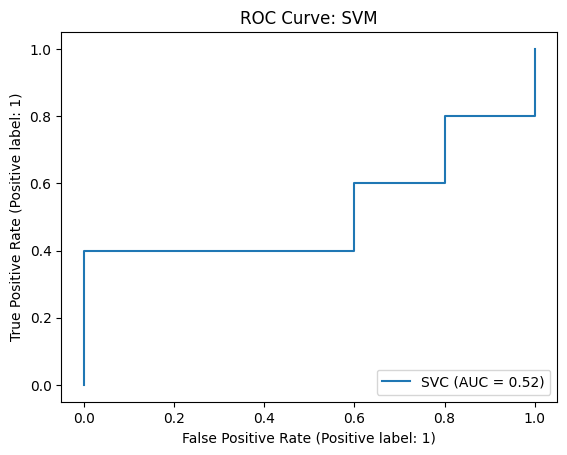

Accuracy: 0.5000
F1 Score: 0.4949
Recall: 0.5000
Confusion Matrix:
[[2 3]
 [2 3]]
ROC AUC Score: 0.5200

Classifier: k-NN


OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

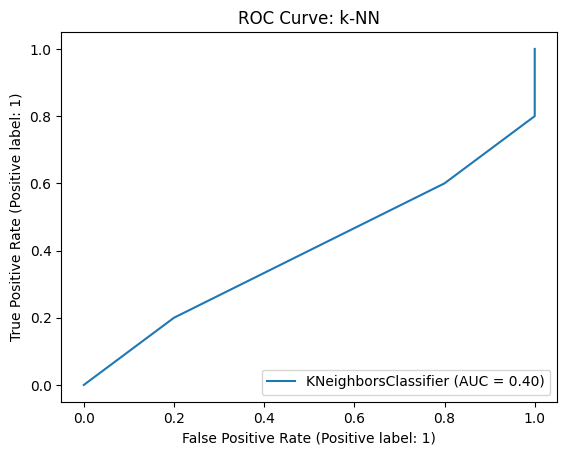

Accuracy: 0.4000
F1 Score: 0.3750
Recall: 0.4000
Confusion Matrix:
[[1 4]
 [2 3]]
ROC AUC Score: 0.4000

Classifier: Naive Bayes


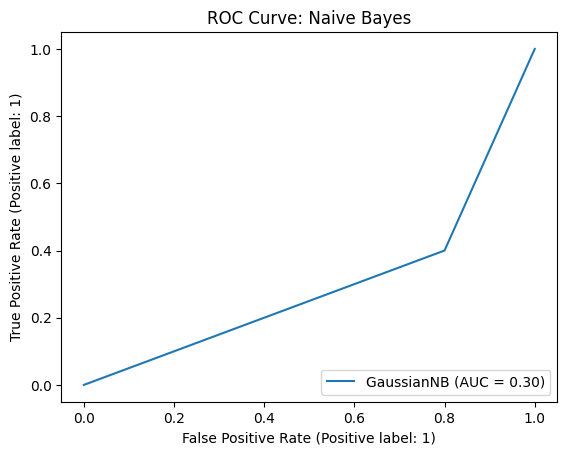

Accuracy: 0.3000
F1 Score: 0.2929
Recall: 0.3000
Confusion Matrix:
[[1 4]
 [3 2]]
ROC AUC Score: 0.3000

Classifier: Logistic Regression


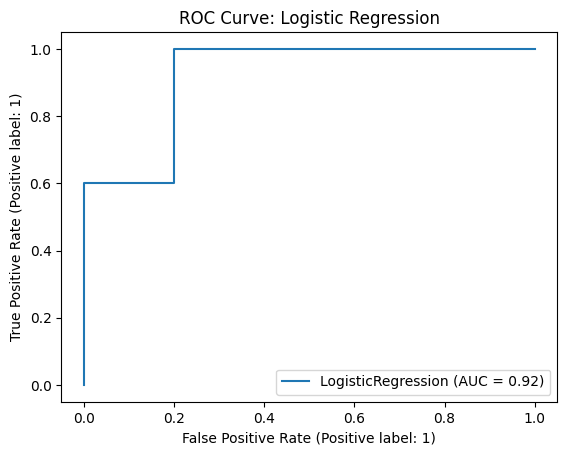

Accuracy: 0.7000
F1 Score: 0.6703
Recall: 0.7000
Confusion Matrix:
[[2 3]
 [0 5]]
ROC AUC Score: 0.9200

Classifier: Gradient Boosting


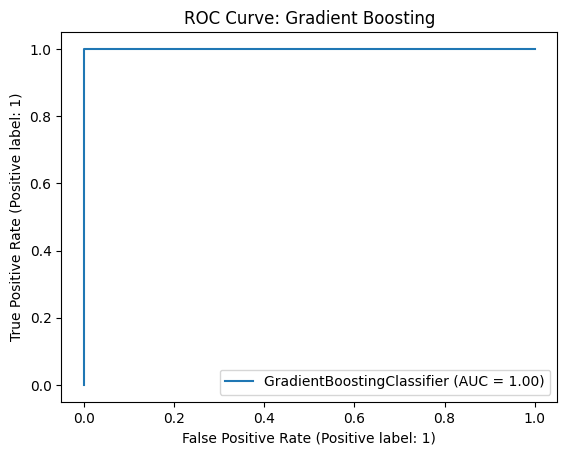

Accuracy: 1.0000
F1 Score: 1.0000
Recall: 1.0000
Confusion Matrix:
[[5 0]
 [0 5]]
ROC AUC Score: 1.0000


In [29]:
# Loop through classifiers
for name, clf in classifiers.items():
    print(f"\nClassifier: {name}")
    
    # Train the classifier
    clf.fit(X_aug, y_aug)
    
    # Make predictions
    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
    
    # Accuracy, F1, Recall
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # ROC AUC score
    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        RocCurveDisplay.from_estimator(clf, X_test_scaled, y_test)
        plt.title(f"ROC Curve: {name}")
        plt.show()
    else:
        roc_auc = None
    
    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    if roc_auc is not None:
        print(f"ROC AUC Score: {roc_auc:.4f}")